In [1]:
from pyiron_workflow import Workflow
from pyiron import Project
from pyiron_atomistics import Atoms
import math

In [2]:
@Workflow.wrap.as_function_node("project")
def create_project(projectPath : str) -> Project:
    return Project(path=projectPath)

@Workflow.wrap.as_function_node("structure")
def create_structure_bulk(project : Project) -> Atoms:
    originalStructure = project.create.structure.bulk("FeAl", crystalstructure="cesiumchloride", a=2.9, cubic=True)
    originalStructure = originalStructure.repeat([2, 2, 2])
    return originalStructure

@Workflow.wrap.as_function_node("structure")
def create_vacancy_Al(structure : Atoms, position : int) -> Atoms:
    vacancyAl = structure.copy()
    del vacancyAl[position]
    return vacancyAl

@Workflow.wrap.as_function_node("structure")
def create_vacancy_Fe(structure : Atoms, position : int) -> Atoms:
    vacancyFe = structure.copy()
    del vacancyFe[position]
    return vacancyFe

@Workflow.wrap.as_function_node("structure")
def create_antisite_Al(structure : Atoms, position : int) -> Atoms:
    antisiteAl = structure.copy()
    antisiteAl[position] = "Fe"
    return antisiteAl

@Workflow.wrap.as_function_node("structure")
def create_antisite_Fe(structure : Atoms, position : int) -> Atoms:
    antisiteFe = structure.copy()
    antisiteFe[position] = "Al"
    return antisiteFe

@Workflow.wrap.as_function_node("structure")
def relax_structure_gpaw(project : Project, structure : Atoms) -> Atoms:
    relax_job = project.create.job.Gpaw("relax_defect", delete_existing_job=True)
    relax_job.structure = structure
    relax_job.calc_minimize()
    relax_job.run()
    relaxedStructure = relax_job.get_structure()
    return relaxedStructure

@Workflow.wrap.as_function_node("structure")
def relax_structure_sphinx(project : Project, structure : Atoms) -> Atoms:
    relax_job = project.create.job.Sphinx("relax_defect", delete_existing_job=True)
    relax_job.structure = structure
    relax_job.calc_minimize()
    relax_job.run()
    relaxedStructure = relax_job.get_structure()
    return relaxedStructure

@Workflow.wrap.as_function_node("energy")
def run_gpaw(project : Project, structure : Atoms) -> float:
    calc_energy_job = project.create.job.Gpaw("calc_energy", delete_existing_job=True)
    calc_energy_job.structure = structure
    calc_energy_job.run()
    energy = calc_energy_job.output.energy_tot[0]
    return energy

@Workflow.wrap.as_function_node("energy")
def run_sphinx(project : Project, structure : Atoms) -> float:
    calc_energy_job = project.create.job.Sphinx("calc_energy", delete_existing_job=True)
    calc_energy_job.structure = structure
    calc_energy_job.run()
    energy = calc_energy_job.output.energy_tot[0]
    return energy

@Workflow.wrap.as_function_node("chemPotentialAl")
def calc_chem_pot_Al(chemPotentialAl : float) -> float:
    chemPotential = chemPotentialAl
    return chemPotential

@Workflow.wrap.as_function_node("chemPotentialFe")
def calc_chem_pot_Fe(chemPotentialAl : float) -> float:
    H_f = -0.662 # formation enthalpy of FeAl
    chemPotential = H_f - chemPotentialAl
    return chemPotential

@Workflow.wrap.as_function_node("defectFormationEnergy")
def calculate_defect_formation_energy(energyDefect : float, energyOriginal : float, chemPotential : float) -> float:
    defectFormationEnergy = energyDefect - energyOriginal + chemPotential
    return defectFormationEnergy

@Workflow.wrap.as_function_node("defectConcentration")
def calc_defect_concentration(defectFormationEnergy : float) -> float:
    k_B = 0.0000862
    temp = 1000
    concentration_defect = math.exp(-defectFormationEnergy/(k_B * temp))
    return concentration_defect

@Workflow.wrap.as_function_node("AlConcentration")
def calc_Al_concentration(defectConcentration1 : float, defectConcentration2 : float) -> float:
    concentration_Al = 0
    return concentration_Al


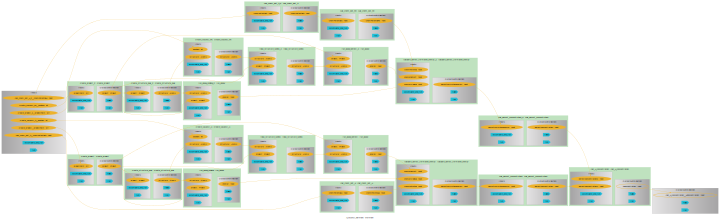

In [5]:
# separate workflows
defect_wf = Workflow("Al_vacancy_workflow")

defect_wf.create_project = create_project("Al_vacancy_workflow")
defect_wf.create_structure_bulk = create_structure_bulk(project = defect_wf.create_project)
defect_wf.create_vacancy_Al = create_vacancy_Al(structure = defect_wf.create_structure_bulk, position = 1)
defect_wf.relax_structure_sphinx = relax_structure_sphinx(project = defect_wf.create_project, structure = defect_wf.create_vacancy_Al)
defect_wf.run_gpaw_original = run_gpaw(project = defect_wf.create_project, structure = defect_wf.create_structure_bulk)
defect_wf.run_gpaw_defect = run_gpaw(project = defect_wf.create_project, structure = defect_wf.relax_structure_sphinx)
defect_wf.calc_chem_pot_Al = calc_chem_pot_Al(chemPotentialAl=0.0)
defect_wf.calculate_defect_formation_energy = calculate_defect_formation_energy(energyDefect = defect_wf.run_gpaw_defect, energyOriginal = defect_wf.run_gpaw_original, chemPotential = defect_wf.calc_chem_pot_Al)
defect_wf.calc_defect_concentration = calc_defect_concentration(defectFormationEnergy = defect_wf.calculate_defect_formation_energy)

defect_wf.create_project_2 = create_project("Fe_vacancy_workflow")
defect_wf.create_structure_bulk_2 = create_structure_bulk(project = defect_wf.create_project_2)
defect_wf.create_vacancy_Fe = create_vacancy_Fe(structure = defect_wf.create_structure_bulk_2, position = 0)
defect_wf.relax_structure_sphinx_2 = relax_structure_sphinx(project = defect_wf.create_project_2, structure = defect_wf.create_vacancy_Fe)
defect_wf.run_gpaw_original_2 = run_gpaw(project = defect_wf.create_project_2, structure = defect_wf.create_structure_bulk_2)
defect_wf.run_gpaw_defect_2 = run_gpaw(project = defect_wf.create_project_2, structure = defect_wf.relax_structure_sphinx_2)
defect_wf.calc_chem_pot_Al_2 = calc_chem_pot_Al(chemPotentialAl=0.0)
defect_wf.calc_chem_pot_Fe = calc_chem_pot_Fe(chemPotentialAl=defect_wf.calc_chem_pot_Al_2)
defect_wf.calculate_defect_formation_energy_2 = calculate_defect_formation_energy(energyDefect = defect_wf.run_gpaw_defect_2, energyOriginal = defect_wf.run_gpaw_original_2, chemPotential = defect_wf.calc_chem_pot_Fe)
defect_wf.calc_defect_concentration_2 = calc_defect_concentration(defectFormationEnergy =  defect_wf.calculate_defect_formation_energy_2)

defect_wf.calc_Al_concentration = calc_Al_concentration(defectConcentration1 = defect_wf.calc_defect_concentration, defectConcentration2 = defect_wf.calc_defect_concentration_2)



defect_wf.draw(size=(10,10))
#defect_wf.run()

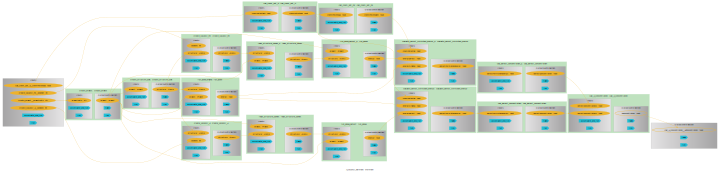

In [4]:
# "interacting" workflows
defect_wf = Workflow("Al_vacancy_workflow")

defect_wf.create_project = create_project("Vacancy_workflow")
defect_wf.create_structure_bulk = create_structure_bulk(project = defect_wf.create_project)
defect_wf.create_vacancy_Al = create_vacancy_Al(structure = defect_wf.create_structure_bulk, position = 1)
defect_wf.relax_structure_sphinx = relax_structure_sphinx(project = defect_wf.create_project, structure = defect_wf.create_vacancy_Al)
defect_wf.run_gpaw_original = run_gpaw(project = defect_wf.create_project, structure = defect_wf.create_structure_bulk)
defect_wf.run_gpaw_defect = run_gpaw(project = defect_wf.create_project, structure = defect_wf.relax_structure_sphinx)
defect_wf.calc_chem_pot_Al = calc_chem_pot_Al(chemPotentialAl=0.0)
defect_wf.calculate_defect_formation_energy = calculate_defect_formation_energy(energyDefect = defect_wf.run_gpaw_defect, energyOriginal = defect_wf.run_gpaw_original, chemPotential = defect_wf.calc_chem_pot_Al)
defect_wf.calc_defect_concentration = calc_defect_concentration(defectFormationEnergy = defect_wf.calculate_defect_formation_energy)

defect_wf.create_vacancy_Fe = create_vacancy_Fe(structure = defect_wf.create_structure_bulk, position = 0)
defect_wf.relax_structure_sphinx_2 = relax_structure_sphinx(project = defect_wf.create_project, structure = defect_wf.create_vacancy_Fe)
defect_wf.run_gpaw_defect_2 = run_gpaw(project = defect_wf.create_project, structure = defect_wf.relax_structure_sphinx_2)
defect_wf.calc_chem_pot_Fe = calc_chem_pot_Fe(chemPotentialAl=defect_wf.calc_chem_pot_Al)
defect_wf.calculate_defect_formation_energy_2 = calculate_defect_formation_energy(energyDefect = defect_wf.run_gpaw_defect_2, energyOriginal = defect_wf.run_gpaw_original, chemPotential = defect_wf.calc_chem_pot_Fe)
defect_wf.calc_defect_concentration_2 = calc_defect_concentration(defectFormationEnergy =  defect_wf.calculate_defect_formation_energy_2)

defect_wf.calc_Al_concentration = calc_Al_concentration(defectConcentration1 = defect_wf.calc_defect_concentration, defectConcentration2 = defect_wf.calc_defect_concentration_2)

defect_wf.draw(size=(10,10))
#defect_wf.run()